In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBClassifier
from scipy import stats
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [2]:
#Load the dataset
pd.read_excel('customer_churn_phase3_prep.xlsx')

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Frequency,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Reason
0,1,0,0,0,2,1,0,DSL,1,1,...,0,Month-to-month,1,Mailed check,3,53.85,108.15,Yes,1,Competitor made better offer
1,0,0,0,1,2,1,0,Fiber optic,0,0,...,0,Month-to-month,1,Electronic check,1,70.70,151.65,Yes,1,Moved
2,0,0,0,1,8,1,1,Fiber optic,0,0,...,1,Month-to-month,1,Electronic check,5,99.65,820.50,Yes,1,Moved
3,0,0,1,1,28,1,1,Fiber optic,0,0,...,1,Month-to-month,1,Electronic check,6,104.80,3046.05,Yes,1,Moved
4,1,0,0,1,49,1,1,Fiber optic,0,1,...,1,Month-to-month,1,Bank transfer (automatic),6,103.70,5036.30,Yes,1,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,0,0,0,72,1,0,No,0,0,...,0,Two year,1,Bank transfer (automatic),1,21.15,1419.40,No,0,Don't know
7028,1,0,1,1,24,1,1,DSL,1,0,...,1,One year,1,Mailed check,7,84.80,1990.50,No,0,Don't know
7029,0,0,1,1,72,1,1,Fiber optic,0,1,...,1,One year,1,Credit card (automatic),6,103.20,7362.90,No,0,Don't know
7030,0,0,1,1,11,0,0,DSL,1,0,...,0,Month-to-month,1,Electronic check,1,29.60,346.45,No,0,Don't know


In [3]:
import pandas as pd
# Perform one-hot-encoding on Internet Service, Contract, and Payment Method simultaneously and convert to integers
df = pd.read_excel('customer_churn_phase3_prep.xlsx')
df = pd.get_dummies(df, columns=['Internet Service', 'Contract', 'Payment Method'])

# Convert boolean columns to integer (1 for True, 0 for False)
# Internet Service
df['Internet Service_DSL'] = df['Internet Service_DSL'].astype(int)
df['Internet Service_Fiber optic'] = df['Internet Service_Fiber optic'].astype(int)
df['Internet Service_No'] = df['Internet Service_No'].astype(int)

# Contract
df['Contract_Month-to-month'] = df['Contract_Month-to-month'].astype(int)
df['Contract_One year'] = df['Contract_One year'].astype(int)
df['Contract_Two year'] = df['Contract_Two year'].astype(int)

# Payment Method
df['Payment Method_Bank transfer (automatic)'] = df['Payment Method_Bank transfer (automatic)'].astype(int)
df['Payment Method_Credit card (automatic)'] = df['Payment Method_Credit card (automatic)'].astype(int)
df['Payment Method_Electronic check'] = df['Payment Method_Electronic check'].astype(int)
df['Payment Method_Mailed check'] = df['Payment Method_Mailed check'].astype(int)

df

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,...,Internet Service_DSL,Internet Service_Fiber optic,Internet Service_No,Contract_Month-to-month,Contract_One year,Contract_Two year,Payment Method_Bank transfer (automatic),Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,1,0,0,0,2,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,1
1,0,0,0,1,2,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
2,0,0,0,1,8,1,1,0,0,1,...,0,1,0,1,0,0,0,0,1,0
3,0,0,1,1,28,1,1,0,0,1,...,0,1,0,1,0,0,0,0,1,0
4,1,0,0,1,49,1,1,0,1,1,...,0,1,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,0,0,0,72,1,0,0,0,0,...,0,0,1,0,0,1,1,0,0,0
7028,1,0,1,1,24,1,1,1,0,1,...,1,0,0,0,1,0,0,0,0,1
7029,0,0,1,1,72,1,1,0,1,1,...,0,1,0,0,1,0,0,1,0,0
7030,0,0,1,1,11,0,0,1,0,0,...,1,0,0,1,0,0,0,0,1,0


In [4]:
# Define features (X) and target (y)
X = df.drop(['Churn Label', 'Churn Value', 'Churn Reason'], axis=1)
y = df['Churn Value']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

display(X.head())
display(y.head())

Shape of X: (7032, 27)
Shape of y: (7032,)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,...,Internet Service_DSL,Internet Service_Fiber optic,Internet Service_No,Contract_Month-to-month,Contract_One year,Contract_Two year,Payment Method_Bank transfer (automatic),Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,1,0,0,0,2,1,0,1,1,0,...,1,0,0,1,0,0,0,0,0,1
1,0,0,0,1,2,1,0,0,0,0,...,0,1,0,1,0,0,0,0,1,0
2,0,0,0,1,8,1,1,0,0,1,...,0,1,0,1,0,0,0,0,1,0
3,0,0,1,1,28,1,1,0,0,1,...,0,1,0,1,0,0,0,0,1,0
4,1,0,0,1,49,1,1,0,1,1,...,0,1,0,1,0,0,1,0,0,0


0    1
1    1
2    1
3    1
4    1
Name: Churn Value, dtype: int64

In [5]:
#Splitting the data
# X are features, Y is the churn value
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

#Verification check
print(f"Training Churn Rate:{y_train.mean():.3f}")
print(f"Test Churn Rate:{y_test.mean():.2f}")

Training Churn Rate:0.266
Test Churn Rate:0.27


Logistic Regression Metrics:
Accuracy: 0.74
Confusion Matrix:
[[1122  427]
 [ 114  447]]
AUC-ROC: 0.85
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.72      0.81      1549
           1       0.51      0.80      0.62       561

    accuracy                           0.74      2110
   macro avg       0.71      0.76      0.71      2110
weighted avg       0.80      0.74      0.76      2110



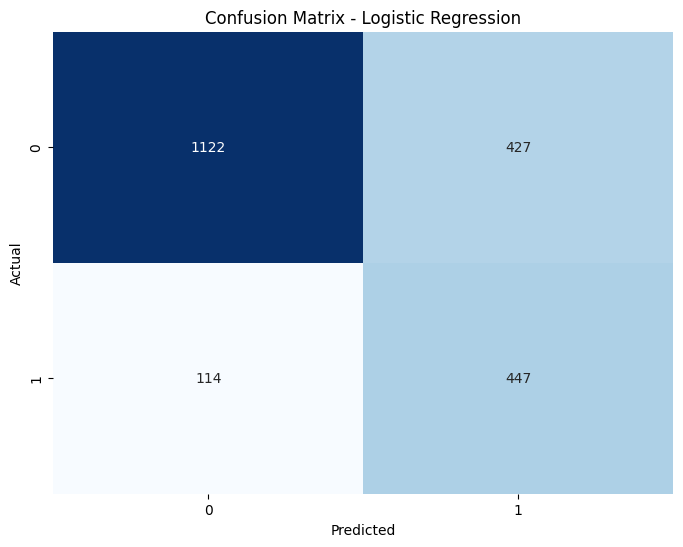

In [6]:
#Build the model
log_reg = LogisticRegression(class_weight='balanced', max_iter=5000, random_state=42)

#Model training
log_reg.fit(X_train, y_train)

#Generate predictions for the ROC Curve
y_pred = log_reg.predict(X_test)
y_probs = log_reg.predict_proba(X_test)[:, 1]

#Evaluate with Metrics
print("Logistic Regression Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"AUC-ROC: {roc_auc_score(y_test, y_probs):.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [7]:
from scipy.sparse import random_array
# XGBoost model
#Define Hyperparameter search space
param_dist = {
    'learning_rate': stats.uniform(0.01, 0.3),
    'max_depth': stats.randint(3, 11),
    'subsample': stats.uniform(0.6, 0.4),
    'colsample_bytree': stats.uniform(0.6, 0.4),
    'n_estimators': stats.randint(100,1000),
    'reg_alpha': stats.uniform(0, 1),
    'reg_lambda': stats.uniform(0, 1),

    }

#Handle imbalance using scale_pos_weight
xgb = XGBClassifier(scale_pos_weight=np.sum(y_train == 0)/np.sum(y_train == 1),
                    eval_metric='logloss',
                    random_state=42 # Corrected typo from randon_state
                    )

# RandonmizedSearchCV with early stopping
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=100,
    scoring='roc_auc',
    n_jobs=-1,
    cv=5,
    verbose=1,
    random_state=42,
    refit=True
)

# Define fit parameters for early stopping
fit_params = {
    'eval_set': [(X_train, y_train), (X_test, y_test)],
    # 'early_stopping_rounds': 10, # Removed this as it caused a TypeError
    'verbose': False
}

# Fit the random search to the data, passing fit_params
random_search.fit(X_train, y_train, **fit_params)

#Get the best model
best_xgb = random_search.best_estimator_

#Predict using the best model
y_pred_xgb = best_xgb.predict(X_test)
y_probs_xgb = best_xgb.predict_proba(X_test)[:, 1]

#Evaluate
print("XGBoost AUC:",roc_auc_score(y_test, y_probs_xgb))
print("Best Parameter:", random_search.best_params_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
XGBoost AUC: 0.8476212011889679
Best Parameter: {'colsample_bytree': np.float64(0.7910859563520911), 'learning_rate': np.float64(0.034867396508006264), 'max_depth': 3, 'n_estimators': 216, 'reg_alpha': np.float64(0.9632225394406113), 'reg_lambda': np.float64(0.012154474689816341), 'subsample': np.float64(0.9879515306830556)}


AUC-ROC: 0.85


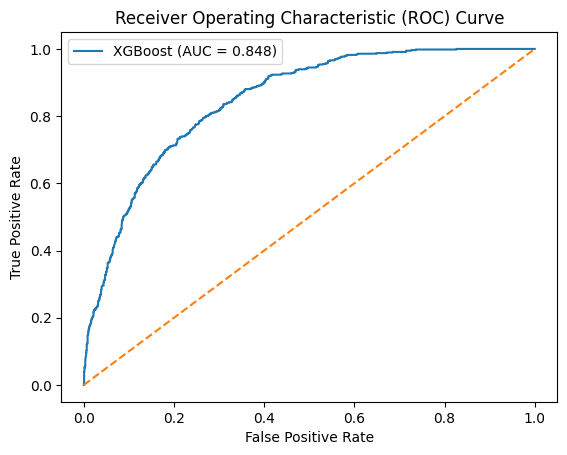

In [8]:
#Using AUC-ROC as they are ideal for class imbalance cases

#Compute AUC
auc = roc_auc_score(y_test, y_probs_xgb)
print(f"AUC-ROC: {auc:.2f}")

#Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs_xgb)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()


In [9]:
pip install lifetimes

   ---------------------------------------- 0.0/584.2 kB ? eta -:--:--
   ---------------------------------------- 584.2/584.2 kB 7.0 MB/s  0:00:00

   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ---------------------------------------- 0/3 [dill]
   ------------- -------------------------- 1/3 [autograd]
   ------------- -------------------------- 1/3 [autograd]
   ------------- -------------------------- 1/3 [autograd]
   ------------- -------------------------- 1/3 [autograd]
   -------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\zuhai\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


LTV Calculations

In [10]:
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter
from lifetimes.utils import calibration_and_holdout_data, summary_data_from_transaction_data

# Create a customer_id from the index for the lifetimes library
df_ltv = df.copy()
df_ltv['customer_id'] = df_ltv.index


# For frequency, we can use 'Total Frequency'
df_ltv['frequency'] = df_ltv['Total Frequency']

# For T (customer's age), we can use 'Tenure Months'
df_ltv['T'] = df_ltv['Tenure Months']

# If frequency is 0, recency is 0.
df_ltv['recency'] = df_ltv.apply(lambda row: row['T'] if row['frequency'] > 0 else 0, axis=1)

# Handle cases where frequency is 0 to avoid division by zero.
df_ltv['monetary_value'] = df_ltv.apply(
    lambda row: row['Total Charges'] / row['frequency'] if row['frequency'] > 0 else 0,
    axis=1
)



df_summary = df_ltv[['customer_id', 'frequency', 'recency', 'T', 'monetary_value']].copy()



# Let's adjust frequency for `lifetimes` if it means *repeat* purchases:
df_summary['frequency_bg_nbd'] = df_summary['frequency'].apply(lambda x: x -1 if x > 0 else 0)


df_active_customers = df_summary[df_summary['frequency_bg_nbd'] > 0]

print("Prepared data for LTV calculation:")
display(df_summary.head())
print("\nSummary for active customers (frequency_bg_nbd > 0):")
display(df_active_customers.head())
print(f"Number of active customers: {len(df_active_customers)}")

Prepared data for LTV calculation:


,customer_id,frequency,recency,T,monetary_value,frequency_bg_nbd
0,0,3,2,2,36.050000,2
1,1,1,2,2,151.650000,0
2,2,5,8,8,164.100000,4
3,3,6,28,28,507.675000,5
4,4,6,49,49,839.383333,5



Summary for active customers (frequency_bg_nbd > 0):


,customer_id,frequency,recency,T,monetary_value,frequency_bg_nbd
0,0,3,2,2,36.050000,2
2,2,5,8,8,164.100000,4
3,3,6,28,28,507.675000,5
4,4,6,49,49,839.383333,5
5,5,3,10,10,176.116667,2


Number of active customers: 5255


In [11]:
# Fit the BG/NBD model
bgf = BetaGeoFitter(penalizer_coef=0.1)


if not df_active_customers.empty:
    bgf.fit(
        df_active_customers['frequency_bg_nbd'],
        df_active_customers['recency'],
        df_active_customers['T']
    )
    print("BG/NBD model fitted successfully.")
    print(bgf)
else:
    print("Not enough active customers with repeat purchases to fit BG/NBD model.")


# Fit the Gamma-Gamma model (for monetary value)
# This model only considers customers who have made repeat purchases and have positive monetary value
gg_fitter = GammaGammaFitter(penalizer_coef=0.01)

# Filter for customers with monetary_value > 0 for Gamma-Gamma
df_gg_fit = df_active_customers[df_active_customers['monetary_value'] > 0]

if not df_gg_fit.empty:
    gg_fitter.fit(
        df_gg_fit['frequency_bg_nbd'],
        df_gg_fit['monetary_value']
    )
    print("\nGamma-Gamma model fitted successfully.")
    print(gg_fitter)
else:
    print("Not enough active customers with positive monetary value and repeat purchases to fit Gamma-Gamma model.")

BG/NBD model fitted successfully.
<lifetimes.BetaGeoFitter: fitted with 5255 subjects, a: 0.00, alpha: 8.27, b: 0.00, r: 1.05>

Gamma-Gamma model fitted successfully.
<lifetimes.GammaGammaFitter: fitted with 5255 subjects, p: 3.50, q: 0.29, v: 3.39>


In [12]:
# Predict future transactions for the next 12 months
if not df_active_customers.empty:
    df_active_customers['predicted_purchases_12_months'] = bgf.predict(
        12, # Predict for 12 months
        df_active_customers['frequency_bg_nbd'],
        df_active_customers['recency'],
        df_active_customers['T']
    )
    print("\nPredicted future purchases for active customers:")
    display(df_active_customers[['customer_id', 'frequency_bg_nbd', 'T', 'predicted_purchases_12_months']].head())
else:
    print("Cannot predict future purchases as BG/NBD model was not fitted.")

# Calculate Conditional Expected Average Profit (CEAP)
if not df_gg_fit.empty and not df_active_customers.empty:
    df_active_customers['CEAP'] = gg_fitter.conditional_expected_average_profit(
        df_active_customers['frequency_bg_nbd'],
        df_active_customers['monetary_value']
    )
    print("\nConditional Expected Average Profit for active customers:")
    display(df_active_customers[['customer_id', 'frequency_bg_nbd', 'monetary_value', 'CEAP']].head())
else:
    print("Cannot calculate Conditional Expected Average Profit as Gamma-Gamma model was not fitted or no active customers.")

# Calculate Customer Lifetime Value (CLTV)
# LTV = CEAP * Predicted Purchases
if 'predicted_purchases_12_months' in df_active_customers.columns and 'CEAP' in df_active_customers.columns:
    df_active_customers['CLTV_12_months'] = (
        df_active_customers['predicted_purchases_12_months'] *
        df_active_customers['CEAP']
    )
    print("\nCustomer Lifetime Value for the next 12 months for active customers:")
    display(df_active_customers[['customer_id', 'CLTV_12_months']].sort_values(by='CLTV_12_months', ascending=False).head())

    # Merge CLTV back to the original df_summary (for all customers)
    df_summary = df_summary.merge(df_active_customers[['customer_id', 'CLTV_12_months']], on='customer_id', how='left')
    df_summary['CLTV_12_months'] = df_summary['CLTV_12_months'].fillna(0) # Customers not in active_customers have 0 CLTV

    print("\nCustomer Lifetime Value (including non-active customers, with 0 LTV):")
    display(df_summary[['customer_id', 'frequency', 'recency', 'T', 'monetary_value', 'CLTV_12_months']].sort_values(by='CLTV_12_months', ascending=False).head())

    # Overall average LTV
    average_ltv = df_summary['CLTV_12_months'].mean()
    print(f"\nOverall Average Customer Lifetime Value (12 months): ${average_ltv:.2f}")
else:
    print("Cannot calculate CLTV. Check if predicted purchases and CEAP are available.")


Predicted future purchases for active customers:


,customer_id,frequency_bg_nbd,T,predicted_purchases_12_months
0,0,2,2,3.562241
2,2,4,8,3.723666
3,3,5,28,2.001263
4,4,5,49,1.267445
5,5,2,10,2.002508



Conditional Expected Average Profit for active customers:


,customer_id,frequency_bg_nbd,monetary_value,CEAP
0,0,2,36.050000,42.022122
2,2,4,164.100000,173.789422
3,3,5,507.675000,529.920420
4,4,5,839.383333,875.701409
5,5,2,176.116667,197.954163



Customer Lifetime Value for the next 12 months for active customers:


,customer_id,CLTV_12_months
1206,1206,1345.983213
3473,3473,1344.130896
5243,5243,1344.070046
6839,6839,1343.706002
5805,5805,1331.979139



Customer Lifetime Value (including non-active customers, with 0 LTV):


,customer_id,frequency,recency,T,monetary_value,CLTV_12_months
1206,1206,8,72,72,1085.60000,1345.983213
3473,3473,8,71,71,1070.59375,1344.130896
5243,5243,8,72,72,1084.05625,1344.070046
6839,6839,8,72,72,1083.76250,1343.706002
5805,5805,8,72,72,1074.30000,1331.979139



Overall Average Customer Lifetime Value (12 months): $542.76


In [13]:
# Merge 'Churn Label' from the original df to df_summary
# First, ensure customer_id exists in original df for merging
df_original_churn = df[['Churn Label']].copy()
df_original_churn['customer_id'] = df_original_churn.index

df_summary_with_churn = df_summary.merge(df_original_churn, on='customer_id', how='left')

# Calculate the average CLTV for each churn segment
ltv_by_churn_segment = df_summary_with_churn.groupby('Churn Label')['CLTV_12_months'].mean().reset_index()
ltv_by_churn_segment = ltv_by_churn_segment.rename(columns={'CLTV_12_months': 'Average_CLTV_12_months'})

print("Average CLTV by Churn Segment:")
display(ltv_by_churn_segment.sort_values(by='Average_CLTV_12_months', ascending=False))

# Identify the churn segment with the highest average LTV
highest_ltv_segment = ltv_by_churn_segment.loc[ltv_by_churn_segment['Average_CLTV_12_months'].idxmax()]
print(f"\nThe churn segment with the highest average LTV is '{highest_ltv_segment['Churn Label']}' with an average CLTV of ${highest_ltv_segment['Average_CLTV_12_months']:.2f}.")

Average CLTV by Churn Segment:


,Churn Label,Average_CLTV_12_months
0,No,555.485049
1,Yes,507.614786



The churn segment with the highest average LTV is 'No' with an average CLTV of $555.49.


In [14]:
# Create a copy of the original dataframe to build the export file
export_df = df.copy()

# Add customer_id from the index
export_df['CustomerID'] = export_df.index

# --- Reconstruct 'Contract' column from one-hot encoded features ---
def get_contract_type(row):
    if row['Contract_Month-to-month'] == 1:
        return 'Month-to-month'
    elif row['Contract_One year'] == 1:
        return 'One year'
    elif row['Contract_Two year'] == 1:
        return 'Two year'
    return None # Should not happen if all are covered

export_df['Contract'] = export_df.apply(get_contract_type, axis=1)

# --- Calculate Churn Probability for the entire dataset ---
# Ensure X is the feature set for the entire dataset
X_full = df.drop(['Churn Label', 'Churn Value', 'Churn Reason'], axis=1)
# Use the trained Logistic Regression model to predict probabilities
export_df['Churn Probability'] = log_reg.predict_proba(X_full)[:, 1]

# --- Merge CLTV from df_summary_with_churn ---
# Ensure customer_id is used for merging
export_df = export_df.merge(df_summary_with_churn[['customer_id', 'CLTV_12_months']], left_on='CustomerID', right_on='customer_id', how='left')
export_df['CLTV_12_months'] = export_df['CLTV_12_months'].fillna(0) # Fill NaN for non-active customers

# --- Select and rename columns for the final export ---
final_export_df = export_df[[
    'CustomerID',
    'Churn Probability',
    'Monthly Charges',
    'Tenure Months',
    'Contract',
    'CLTV_12_months'
]].copy()

final_export_df = final_export_df.rename(columns={'CLTV_12_months': 'CLTV'})

display(final_export_df.head())
print(f"Shape of the final export DataFrame: {final_export_df.shape}")

,CustomerID,Churn Probability,Monthly Charges,Tenure Months,Contract,CLTV
0,0,0.571694,53.85,2,Month-to-month,149.692911
1,1,0.544678,70.70,2,Month-to-month,0.000000
2,2,0.665208,99.65,8,Month-to-month,647.133756
3,3,0.522938,104.80,28,Month-to-month,1060.510274
4,4,0.295864,103.70,49,Month-to-month,1109.903364


Shape of the final export DataFrame: (7032, 6)


In [15]:
# Export the DataFrame to an Excel file
excel_file_name = 'part5_dataset.xlsx'
final_export_df.to_excel(excel_file_name, index=False)

print(f"Data successfully exported to '{excel_file_name}'.")

PermissionError: [Errno 13] Permission denied: 'part5_dataset.xlsx'